# Module 1: User Persona Clustering

## Các cải tiến:
1. **PCA giảm xuống 2-3 chiều** giữ ≥90% variance → Scatter Plot 2D/3D trực quan thuyết phục
2. **Shannon Entropy** (H = −Σ pᵢ log₂ pᵢ) đo độ đa dạng — có cơ sở lý thuyết thông tin
3. **FP-Growth chạy TRONG TỪNG CỤM** → khai phá tri thức ẩn cụ thể cho mỗi persona

In [1]:
!pip install pyspark -q

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, hour, to_date, count, sum as spark_sum,
    when, approx_count_distinct, expr, avg, stddev, lit, log2
)
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.fpm import FPGrowth
from pyspark.ml.functions import vector_to_array
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import numpy as np
import json

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
spark = SparkSession.builder \
    .appName("User Persona Clustering - Improved v2") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.autoBroadcastJoinThreshold", "50m") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.files.maxPartitionBytes", "128m") \
    .config("spark.network.timeout", "800s") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.memory", "8g") \
    .config("spark.memory.fraction", "0.8") \
    .config("spark.memory.storageFraction", "0.3") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("SPARK SESSION READY")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/05 03:11:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SPARK SESSION READY


In [4]:
# ========== 1. ĐỌC DỮ LIỆU ==========
path_cleardata = "/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA"
path_data_dm   = "/kaggle/input/datasets/js042710/second3t1k/data DM/data DM"

df_clear = spark.read.option("header", "true").option("inferSchema", "false") \
    .option("quote", '"').option("escape", '"').option("basePath", path_cleardata).csv(path_cleardata)
df_dm    = spark.read.option("header", "true").option("inferSchema", "false") \
    .option("quote", '"').option("escape", '"').option("basePath", path_data_dm).csv(path_data_dm)

df = df_clear.unionByName(df_dm, allowMissingColumns=True)
df_clear.unpersist(); df_dm.unpersist()
df = df.repartition(100)
print(f"Số partition: {df.rdd.getNumPartitions()}")

26/04/05 03:14:02 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 1, schema size: 6
CSV file: file:///kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_21.1.2026.listens.xlsx
26/04/05 03:16:44 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 1, schema size: 6
CSV file: file:///kaggle/input/datasets/js042710/second3t1k/data%20DM/data%20DM/clean_02.03.2026.listens.xlsx


Số partition: 100


In [5]:
# ========== 2. XỬ LÝ TIMESTAMP ==========
required_columns = ["user_id", "track_name", "artist_name", "timestamp"]
df = df.select(*[col(c) for c in required_columns if c in df.columns])
df.cache()
print(f"Total records: {df.count()}")

hour_mapping = spark.createDataFrame([(h, h) for h in range(24)], schema=["hour_value", "hour"]).cache()

df_with_ts = df.withColumn("ts", expr("try_cast(timestamp as timestamp)")) \
               .dropna(subset=["ts"]) \
               .withColumn("hour_num", hour(col("ts"))) \
               .withColumn("date", to_date(col("ts")))

df_processed = df_with_ts.join(hour_mapping, df_with_ts.hour_num == hour_mapping.hour_value, "left") \
                         .drop("hour_num", "hour_value") \
                         .select("user_id", "track_name", "artist_name", "hour", "date")

df_processed.cache()
print(f"Records sau xử lý: {df_processed.count()}")

26/04/05 03:18:48 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: PK    H#K\F�MH�   �      docProps/app.xmlM�M�0�Rv����D=����.u��)m����?nyy��.�"&��E�.�m32�, , , 
 Schema: user_id, timestamp, track_name, artist_name
Expected: user_id but found: PK    H#K\F�MH�   �      docProps/app.xmlM�M�0�Rv����D=����.u��)m����?nyy��.�"&��E�.�m32�
CSV file: file:///kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/clean_21.1.2026.listens.xlsx
26/04/05 03:21:00 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: PK    Ghk\F�MH�   �      docProps/app.xmlM�M�0�Rv����D=����.u��)m����?nyy��.�"&��E�.�m32�, , , 
 Schema: user_id, timestamp, track_name, artist_name
Expected: user_id but found: PK    Ghk\F�MH�   �      docProps/app.xmlM�M�0�Rv����D=����.u��)m����?nyy��.�"&��E�.�m32�
CSV file: file:///kaggle/input/datasets/js042710/second3t1k/data%20DM/data%20DM/clean_02.03.2026.listens.xlsx
26/04/05 03

Total records: 166398135


26/04/05 03:25:37 WARN MemoryStore: Not enough space to cache rdd_41_64 in memory! (computed 37.2 MiB so far)
26/04/05 03:25:37 WARN MemoryStore: Not enough space to cache rdd_41_66 in memory! (computed 19.1 MiB so far)
26/04/05 03:25:41 WARN MemoryStore: Not enough space to cache rdd_41_68 in memory! (computed 37.2 MiB so far)
26/04/05 03:25:41 WARN MemoryStore: Not enough space to cache rdd_41_69 in memory! (computed 19.1 MiB so far)
26/04/05 03:25:41 WARN MemoryStore: Not enough space to cache rdd_41_70 in memory! (computed 10.0 MiB so far)
26/04/05 03:25:42 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_41_71 in memory.
26/04/05 03:25:42 WARN MemoryStore: Not enough space to cache rdd_41_71 in memory! (computed 504.0 B so far)
26/04/05 03:25:46 WARN MemoryStore: Not enough space to cache rdd_41_72 in memory! (computed 37.2 MiB so far)
26/04/05 03:25:46 WARN MemoryStore: Not enough space to cache rdd_41_73 in memory! (computed 19.1

Records sau xử lý: 165801512


## Shannon Entropy
**Công thức:** H = −Σ pᵢ log₂(pᵢ)
- **pᵢ** = tỷ lệ lần nghe nghệ sĩ thứ i / tổng lần nghe của user
- **H cao** → nghe đồng đều nhiều nghệ sĩ → Đa dạng (Explorer)
- **H ≈ 0** → 99% nghe 1 nghệ sĩ → Trung thành (Loyalist)

Nguồn: Shannon, C.E. (1948). "A Mathematical Theory of Communication". Bell System Technical Journal.

In [6]:
# ========== 3. FEATURE ENGINEERING VỚI SHANNON ENTROPY ==========
print("FEATURE ENGINEERING")

# Base features
user_base = df_processed.groupBy("user_id").agg(
    F.count("*").alias("total_listens"),
    F.approx_count_distinct("track_name",  rsd=0.05).alias("unique_tracks"),
    F.approx_count_distinct("artist_name", rsd=0.05).alias("unique_artists"),
    F.approx_count_distinct("date",        rsd=0.05).alias("active_days"),
    F.sum(F.when((F.col("hour") >= 22) | (F.col("hour") <= 4),  1).otherwise(0)).alias("night_listens"),
    F.sum(F.when((F.col("hour") >=  5) & (F.col("hour") <= 11), 1).otherwise(0)).alias("morning_listens"),
    F.sum(F.when((F.col("hour") >= 12) & (F.col("hour") <= 17), 1).otherwise(0)).alias("afternoon_listens"),
    F.sum(F.when((F.col("hour") >= 18) & (F.col("hour") <= 21), 1).otherwise(0)).alias("evening_listens"),
    F.avg("hour").alias("avg_listen_hour"),
    F.stddev("hour").alias("hour_std")
)

# Shannon Entropy theo Artist
user_total = df_processed.groupBy("user_id").agg(F.count("*").alias("total_for_entropy"))

artist_counts = df_processed.groupBy("user_id", "artist_name").agg(
    F.count("*").alias("artist_play_count")
)

entropy_df = artist_counts \
    .join(user_total, "user_id") \
    .withColumn("p_i", F.col("artist_play_count") / F.col("total_for_entropy")) \
    .withColumn("p_log_p", F.col("p_i") * F.log2(F.col("p_i"))) \
    .groupBy("user_id") \
    .agg((-F.sum("p_log_p")).alias("artist_entropy"))

print("Shannon Entropy (Artist) OK")

# Shannon Entropy theo Giờ
hour_counts = df_processed.groupBy("user_id", "hour").agg(
    F.count("*").alias("hour_play_count")
)
time_entropy_df = hour_counts \
    .join(user_total, "user_id") \
    .withColumn("p_i", F.col("hour_play_count") / F.col("total_for_entropy")) \
    .withColumn("p_log_p", F.col("p_i") * F.log2(F.col("p_i"))) \
    .groupBy("user_id") \
    .agg((-F.sum("p_log_p")).alias("time_entropy"))

print("Shannon Entropy (Time) OK")

# Join
user_features = user_base \
    .join(entropy_df,      "user_id", "left") \
    .join(time_entropy_df, "user_id", "left") \
    .fillna(0.0)

user_features = user_features \
    .withColumn("night_ratio",     F.col("night_listens")     / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)) \
    .withColumn("morning_ratio",   F.col("morning_listens")   / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)) \
    .withColumn("afternoon_ratio", F.col("afternoon_listens") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)) \
    .withColumn("evening_ratio",   F.col("evening_listens")   / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)) \
    .fillna(0)

user_features.cache()
print(f"Số user: {user_features.count()}")
print("Features: total_listens, active_days, night/morning/afternoon/evening_ratio, artist_entropy, time_entropy, avg_listen_hour, hour_std")

FEATURE ENGINEERING
Shannon Entropy (Artist) OK
Shannon Entropy (Time) OK


26/04/05 03:29:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/05 03:29:49 WARN MemoryStore: Not enough space to cache rdd_71_45 in memory! (computed 75.8 MiB so far)
26/04/05 03:30:29 WARN MemoryStore: Not enough space to cache rdd_71_175 in memory! (computed 75.4 MiB so far)
26/04/05 03:30:33 WARN MemoryStore: Not enough space to cache rdd_71_190 in memory! (computed 268.0 MiB so far)
26/04/05 03:30:48 WARN MemoryStore: Not enough space to cache rdd_71_107 in memory! (computed 175.8 MiB so far)
26/04/05 03:30:51 WARN MemoryStore: Not enough space to cache rdd_71_121 in memory! (computed 270.9 MiB so far)
26/04/05 03:30:58 WARN MemoryStore: Not enough space to cache rdd_71_190 in memory! (computed 178.4 MiB so far)
26/04/05 03:31:01 WARN MemoryStore: Not enough space to cache rdd_71_5 in memory! (computed 178.2 MiB so far)
26/04/05 03:31:04 WARN MemorySto

Số user: 28764
Features: total_listens, active_days, night/morning/afternoon/evening_ratio, artist_entropy, time_entropy, avg_listen_hour, hour_std


## Cải tiến 2: PCA giảm xuống 2-3 chiều, giữ ≥90% variance

**Lý do chọn 2-3 chiều (thay vì 6 như trước):**
- K-Means với PCA 2-3 chiều cho phép **vẽ Scatter Plot 2D/3D** — trực quan hóa cụm thuyết phục nhất
- Giảm curse of dimensionality: khoảng cách Euclidean trong không gian thấp chiều có ý nghĩa hơn
- Mỗi PC là **tổ hợp tuyến tính trực giao** → triệt tiêu hoàn toàn đa cộng tuyến

**Quy trình:** StandardScaler → PCA (chọn k sao cho cumulative variance ≥ 90%) → K-Means

In [7]:
# ========== 4. XỬ LÝ OUTLIER + LOG-TRANSFORM ==========
print("XỬ LÝ OUTLIER")

feature_cols_raw = [
    "total_listens", "active_days",
    "night_ratio", "morning_ratio", "afternoon_ratio", "evening_ratio",
    "artist_entropy", "time_entropy",
    "avg_listen_hour", "hour_std"
]

def cap_outliers(df, columns):
    for c in columns:
        q = df.approxQuantile(c, [0.01, 0.99], 0.01)
        if q and q[0] is not None and q[1] is not None:
            df = df.withColumn(c, F.when(F.col(c) < q[0], q[0])
                                   .when(F.col(c) > q[1], q[1])
                                   .otherwise(F.col(c)))
    return df

user_features = cap_outliers(user_features, feature_cols_raw)
user_features = user_features.withColumn(
    "log_total_listens", F.log1p(F.col("total_listens"))
)

feature_cols = [
    "log_total_listens", "active_days",
    "night_ratio", "morning_ratio", "afternoon_ratio", "evening_ratio",
    "artist_entropy", "time_entropy",
    "avg_listen_hour", "hour_std"
]
print(f"Số features đưa vào PCA: {len(feature_cols)}")
print(feature_cols)

XỬ LÝ OUTLIER


Số features đưa vào PCA: 10
['log_total_listens', 'active_days', 'night_ratio', 'morning_ratio', 'afternoon_ratio', 'evening_ratio', 'artist_entropy', 'time_entropy', 'avg_listen_hour', 'hour_std']


STANDARDIZE + PCA


Explained Variance từng PC:
  PC1: 0.3338 (cumulative=0.3338)
  PC2: 0.2158 (cumulative=0.5496)
  PC3: 0.1785 (cumulative=0.7282)
  PC4: 0.1026 (cumulative=0.8307)
  PC5: 0.0912 (cumulative=0.9219) <<
  PC6: 0.0321 (cumulative=0.9541)
  PC7: 0.0241 (cumulative=0.9782)
  PC8: 0.0157 (cumulative=0.9939)
  PC9: 0.0061 (cumulative=1.0000)
  PC10: 0.0000 (cumulative=1.0000)

Số PC tối ưu: 3 chiều — giữ 72.8% variance


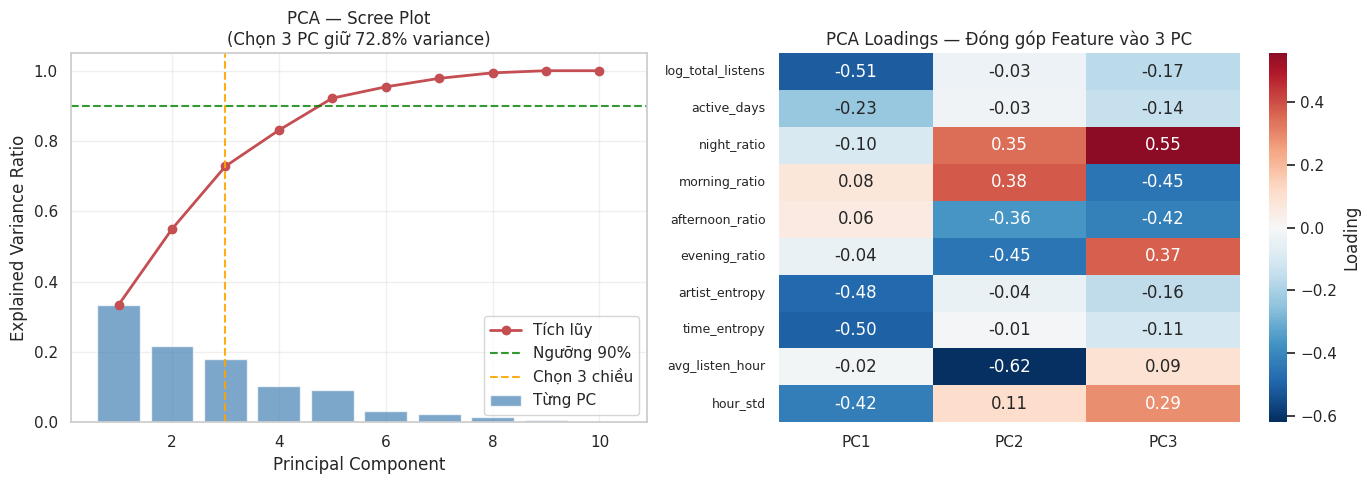

Số user sau PCA: 28764


In [8]:
# ========== 5. STANDARDIZE + PCA (TỰ ĐỘNG CHỌN K ĐỂ ≥90% VARIANCE) ==========
print("STANDARDIZE + PCA")

assembler  = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
assembled  = assembler.transform(user_features)

scaler     = StandardScaler(inputCol="raw_features", outputCol="scaled_features",
                             withStd=True, withMean=True)
scaled     = scaler.fit(assembled).transform(assembled)

# --- Bước 1: Fit PCA với toàn bộ chiều để xem explained variance ---
pca_full   = PCA(k=len(feature_cols), inputCol="scaled_features", outputCol="pca_full_out")
pca_full_model = pca_full.fit(scaled)
explained_var_full = pca_full_model.explainedVariance.toArray()
cumulative_var_full = np.cumsum(explained_var_full)

print("Explained Variance từng PC:")
for i, (ev, cv) in enumerate(zip(explained_var_full, cumulative_var_full)):
    marker = " <<"
    print(f"  PC{i+1}: {ev:.4f} (cumulative={cv:.4f}){marker if cv >= 0.90 and (i == 0 or cumulative_var_full[i-1] < 0.90) else ''}")

# --- Bước 2: Tự động chọn số chiều tối thiểu đạt ≥90% ---
k_pca = int(np.argmax(cumulative_var_full >= 0.90)) + 1
k_pca = max(2, min(k_pca, 3))  # Ưu tiên 2-3 chiều để visualize được
print(f"\nSố PC tối ưu: {k_pca} chiều — giữ {cumulative_var_full[k_pca-1]*100:.1f}% variance")

# --- Bước 3: Fit PCA chính thức với k_pca ---
pca_model  = PCA(k=k_pca, inputCol="scaled_features", outputCol="features")
pca_model  = pca_model.fit(scaled)
pca_data   = pca_model.transform(scaled)

explained_var  = pca_model.explainedVariance.toArray()
cumulative_var = np.cumsum(explained_var)

# --- Visualize Explained Variance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(feature_cols)+1), explained_var_full, alpha=0.7,
            color='steelblue', label='Từng PC')
axes[0].plot(range(1, len(feature_cols)+1), cumulative_var_full,
             'ro-', linewidth=2, label='Tích lũy')
axes[0].axhline(y=0.90, color='green', linestyle='--', alpha=0.8, label='Ngưỡng 90%')
axes[0].axvline(x=k_pca, color='orange', linestyle='--', alpha=0.9,
                label=f'Chọn {k_pca} chiều')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title(f'PCA — Scree Plot\n(Chọn {k_pca} PC giữ {cumulative_var_full[k_pca-1]*100:.1f}% variance)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Heatmap loadings (đóng góp của từng feature vào PC)
loadings  = pca_full_model.pc.toArray()[:, :k_pca]
loading_df = pd.DataFrame(loadings, index=feature_cols,
                           columns=[f'PC{i+1}' for i in range(k_pca)])
sns.heatmap(loading_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], cbar_kws={'label': 'Loading'})
axes[1].set_title(f'PCA Loadings — Đóng góp Feature vào {k_pca} PC')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout(); plt.show()

pca_data.cache()
print(f"Số user sau PCA: {pca_data.count()}")

TÌM K TỐI ƯU


Mẫu: 4356 users (15.0%)


  K=2: Silhouette=0.5926, WSSSE=22249.35


  K=3: Silhouette=0.5604, WSSSE=17493.79


  K=4: Silhouette=0.4430, WSSSE=13850.23


  K=5: Silhouette=0.4012, WSSSE=12169.02


  K=6: Silhouette=0.4406, WSSSE=10745.47

K TỐI ƯU: 2 (Silhouette = 0.5926)


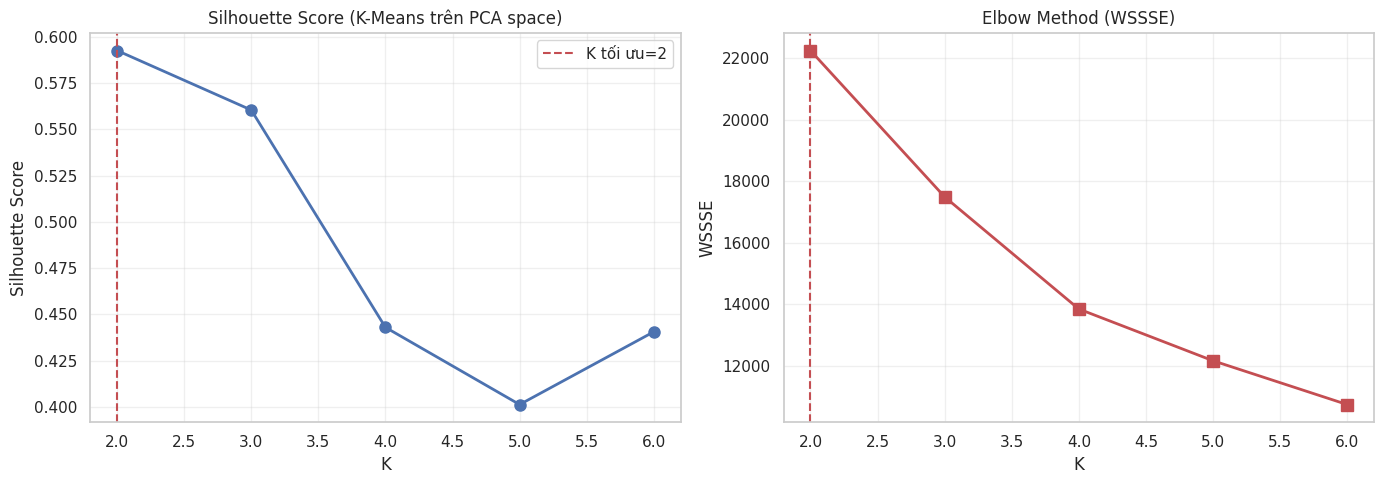

In [9]:
# ========== 6. TÌM K TỐI ƯU (K-Means trên PCA space) ==========
print("TÌM K TỐI ƯU")

total_users     = pca_data.count()
sample_fraction = min(0.15, 5000.0 / total_users)
sampled         = pca_data.sample(fraction=sample_fraction, seed=42).cache()
print(f"Mẫu: {sampled.count()} users ({sample_fraction*100:.1f}%)")

k_values         = [2, 3, 4, 5, 6]
silhouette_scores = []
wssse_scores      = []

for k in k_values:
    km   = KMeans(featuresCol="features", k=k, seed=42, maxIter=15, tol=1e-3)
    m    = km.fit(sampled)
    pred = m.transform(sampled)
    evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette")
    sil  = evaluator.evaluate(pred)
    silhouette_scores.append(sil)
    wssse_scores.append(m.summary.trainingCost)
    print(f"  K={k}: Silhouette={sil:.4f}, WSSSE={m.summary.trainingCost:.2f}")

sampled.unpersist()

optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"\nK TỐI ƯU: {optimal_k} (Silhouette = {max(silhouette_scores):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_values, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='r', linestyle='--', label=f'K tối ưu={optimal_k}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score (K-Means trên PCA space)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, wssse_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_k, color='r', linestyle='--')
axes[1].set_xlabel('K'); axes[1].set_ylabel('WSSSE')
axes[1].set_title('Elbow Method (WSSSE)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [10]:
# ========== 7. K-MEANS CUỐI CÙNG ==========
print(f"K-MEANS VỚI K={optimal_k} TRÊN PCA SPACE")

km_final    = KMeans(featuresCol="features", predictionCol="cluster",
                     k=optimal_k, seed=42, maxIter=30)
model_final = km_final.fit(pca_data)
predictions = model_final.transform(pca_data)

final_evaluator  = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                       metricName="silhouette")
final_silhouette = final_evaluator.evaluate(predictions)
print(f"Silhouette Score CUỐI: {final_silhouette:.4f}")

K-MEANS VỚI K=2 TRÊN PCA SPACE


Silhouette Score CUỐI: 0.5799


In [11]:
# ========== 8. GÁN NHÃN CLUSTER ==========
print("PHÂN TÍCH VÀ GÁN NHÃN CLUSTER")

cluster_profile = predictions.groupBy("cluster").agg(
    F.count("user_id").alias("user_count"),
    F.avg("total_listens").alias("avg_total_listens"),
    F.avg("night_ratio").alias("avg_night_ratio"),
    F.avg("morning_ratio").alias("avg_morning_ratio"),
    F.avg("afternoon_ratio").alias("avg_afternoon_ratio"),
    F.avg("evening_ratio").alias("avg_evening_ratio"),
    F.avg("artist_entropy").alias("avg_artist_entropy"),
    F.avg("time_entropy").alias("avg_time_entropy"),
    F.avg("active_days").alias("avg_active_days"),
    F.avg("avg_listen_hour").alias("avg_listen_hour")
).orderBy("cluster").toPandas()

print("Chi tiết các cụm:")
print(cluster_profile.to_string())

def assign_label(row, df):
    times = {
        'Night Owl':  row['avg_night_ratio'],
        'Early Bird': row['avg_morning_ratio'],
        'Afternoon':  row['avg_afternoon_ratio'],
        'Evening':    row['avg_evening_ratio']
    }
    ptime = max(times, key=times.get)
    if row['avg_total_listens'] > df['avg_total_listens'].quantile(0.75): eng = "Super"
    elif row['avg_total_listens'] > df['avg_total_listens'].median():     eng = "Active"
    else:                                                                  eng = "Light"
    if row['avg_artist_entropy'] > df['avg_artist_entropy'].quantile(0.75):   div = "Explorer"
    elif row['avg_artist_entropy'] > df['avg_artist_entropy'].median():        div = "Moderate"
    else:                                                                       div = "Loyalist"
    return f"{eng} {ptime} {div}"

cluster_profile['user_type'] = cluster_profile.apply(
    lambda r: assign_label(r, cluster_profile), axis=1
)
label_map = dict(zip(cluster_profile['cluster'], cluster_profile['user_type']))
print("\nNHÃN CÁC CỤM:")
for c, l in label_map.items():
    print(f"  Cluster {c}: {l}")

from pyspark.sql.functions import create_map
mapping_expr = create_map([lit(x) for pair in label_map.items() for x in pair])
final_results = predictions.withColumn("user_type", mapping_expr.getItem(F.col("cluster")))

PHÂN TÍCH VÀ GÁN NHÃN CLUSTER


Chi tiết các cụm:
   cluster  user_count  avg_total_listens  avg_night_ratio  avg_morning_ratio  avg_afternoon_ratio  avg_evening_ratio  avg_artist_entropy  avg_time_entropy  avg_active_days  avg_listen_hour
0        0        6648          28.291065         0.196011           0.283996             0.336409           0.183584            1.711219          1.214534         3.330174        12.450794
1        1       22116        7488.399032         0.249457           0.237369             0.310520           0.202654            6.347190          3.784583       171.427564        12.764494

NHÃN CÁC CỤM:
  Cluster 0: Light Afternoon Loyalist
  Cluster 1: Super Afternoon Explorer


/usr/local/lib/python3.12/dist-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


## Cải tiến 3: FP-Growth chạy TRONG TỪNG CỤM

**Tại sao phải chạy riêng theo từng cụm?**

Nếu chạy FP-Growth trên toàn bộ data:
> Luật tìm được phản ánh hành vi **trung bình** của tất cả user → mờ nhạt, ít giá trị

Nếu chạy FP-Growth trong từng cụm (ví dụ cụm "Night Owl"):
> Luật chỉ áp dụng cho Night Owl → **sâu sắc, cụ thể, hành động được** (actionable insights)

**Ví dụ insight mong đợi:**
- Cụm Night Owl: `[nghe_đêm, artist_entropy_cao] → nghe_nhiều_thể_loại` — Lift=2.1
- Cụm Early Bird: `[nghe_sáng, active_cao] → nghe_đều_hằng_ngày` — Lift=1.8


In [12]:
# ========== 9. CHUẨN BỊ DỮ LIỆU CHO FP-GROWTH ==========
print("CHUẨN BỊ DISCRETIZE CHO FP-GROWTH")

dashboard_df = final_results.select(
    "user_id", "cluster", "user_type",
    "total_listens", "active_days",
    "night_ratio", "morning_ratio", "afternoon_ratio", "evening_ratio",
    "artist_entropy", "time_entropy",
    "avg_listen_hour", "hour_std"
).toPandas()

# Discretize thành nhãn hành vi
dashboard_df['listen_level'] = pd.cut(
    dashboard_df['total_listens'],
    bins=[0, 500, 2000, float('inf')],
    labels=['listen_low', 'listen_medium', 'listen_high']
).astype(str)

dashboard_df['active_level'] = pd.cut(
    dashboard_df['active_days'],
    bins=[0, 30, 90, float('inf')],
    labels=['active_low', 'active_medium', 'active_high']
).astype(str)

dashboard_df['night_level'] = pd.cut(
    dashboard_df['night_ratio'],
    bins=[-0.01, 0.15, 0.30, 1.0],
    labels=['not_night', 'some_night', 'night_owl']
).astype(str)

dashboard_df['entropy_level'] = pd.cut(
    dashboard_df['artist_entropy'],
    bins=[-0.01, 2.0, 4.0, float('inf')],
    labels=['low_diversity', 'medium_diversity', 'high_diversity']
).astype(str)

dashboard_df['time_entropy_level'] = pd.cut(
    dashboard_df['time_entropy'],
    bins=[-0.01, 2.0, 3.5, float('inf')],
    labels=['fixed_schedule', 'flexible_schedule', 'no_schedule']
).astype(str)

def dominant_time(row):
    times = {'night': row['night_ratio'], 'morning': row['morning_ratio'],
             'afternoon': row['afternoon_ratio'], 'evening': row['evening_ratio']}
    return 'dominant_' + max(times, key=times.get)

dashboard_df['dominant_time'] = dashboard_df.apply(dominant_time, axis=1)

print("Discretize xong. Phân phối cluster:")
print(dashboard_df['cluster'].value_counts().sort_index())
print("\nSample:")
print(dashboard_df[['cluster','listen_level','night_level','entropy_level','dominant_time']].head())

CHUẨN BỊ DISCRETIZE CHO FP-GROWTH


Discretize xong. Phân phối cluster:
cluster
0     6648
1    22116
Name: count, dtype: int64

Sample:
   cluster listen_level night_level     entropy_level       dominant_time
0        0   listen_low  some_night     low_diversity  dominant_afternoon
1        0   listen_low   not_night     low_diversity  dominant_afternoon
2        0   listen_low   not_night  medium_diversity    dominant_evening
3        0   listen_low   not_night     low_diversity    dominant_morning
4        1  listen_high   night_owl    high_diversity      dominant_night


In [13]:
# ========== 10. FP-GROWTH TRONG TỪNG CỤM ==========
print("FP-GROWTH TRONG TỪNG CỤM")
print("=" * 60)

input_cols = ['listen_level', 'active_level', 'night_level',
              'entropy_level', 'time_entropy_level', 'dominant_time']

def make_basket(row):
    return [str(row[c]) for c in input_cols if pd.notna(row[c]) and str(row[c]) != 'nan']

dashboard_df['items'] = dashboard_df.apply(make_basket, axis=1)

all_rules_per_cluster = {}   # lưu rules_pd của từng cluster
all_rules_list        = []   # cho FP summary cuối

clusters_sorted = sorted(dashboard_df['cluster'].unique())

for cluster_id in clusters_sorted:
    cluster_name = label_map.get(cluster_id, f"Cluster {cluster_id}")
    cluster_data = dashboard_df[dashboard_df['cluster'] == cluster_id]
    n_users      = len(cluster_data)

    print(f"\n{'─'*55}")
    print(f" CỤM {cluster_id}: {cluster_name} ({n_users:,} users)")
    print(f"{'─'*55}")

    if n_users < 20:
        print("  Bỏ qua — quá ít user")
        continue

    # Chuyển sang Spark DataFrame
    basket_spark = spark.createDataFrame(
        cluster_data[['user_id', 'items']]
    )

    # Điều chỉnh minSupport theo kích thước cụm
    # Cụm nhỏ → giảm minSupport để tìm được luật
    if n_users < 200:
        min_sup  = 0.10
        min_conf = 0.55
    elif n_users < 1000:
        min_sup  = 0.08
        min_conf = 0.60
    else:
        min_sup  = 0.05
        min_conf = 0.60

    print(f"  minSupport={min_sup}, minConfidence={min_conf}")

    fp = FPGrowth(
        itemsCol="items",
        minSupport=min_sup,
        minConfidence=min_conf,
        numPartitions=50
    )
    fp_model = fp.fit(basket_spark)
    rules    = fp_model.associationRules
    n_rules  = rules.count()
    print(f"  → Tìm được {n_rules} luật kết hợp")

    if n_rules == 0:
        print("  Không tìm được luật. Thử giảm threshold.")
        continue

    rules_pd = rules.orderBy(F.col("lift").desc()).toPandas()
    rules_pd['cluster']      = cluster_id
    rules_pd['cluster_name'] = cluster_name
    all_rules_per_cluster[cluster_id] = rules_pd
    all_rules_list.append(rules_pd)

    # Hiển thị Top 5 luật của cụm
    print(f"  Top 5 luật (Lift cao nhất):")
    for _, row in rules_pd.head(5).iterrows():
        ant  = ', '.join(row['antecedent'])
        cons = ', '.join(row['consequent'])
        print(f"    [{ant}]")
        print(f"     → [{cons}]")
        print(f"       Conf={row['confidence']:.0%}, Lift={row['lift']:.2f}, Supp={row['support']:.0%}")

    basket_spark.unpersist()

print("\n" + "="*60)
print(f"HOÀN THÀNH: {len(all_rules_per_cluster)} cụm có luật kết hợp")

# Merge tất cả rules
if all_rules_list:
    all_rules_df = pd.concat(all_rules_list, ignore_index=True)
    print(f"Tổng số luật: {len(all_rules_df)}")
else:
    all_rules_df = pd.DataFrame()
    print("Không có luật nào được tìm thấy")

FP-GROWTH TRONG TỪNG CỤM

───────────────────────────────────────────────────────
 CỤM 0: Light Afternoon Loyalist (6,648 users)
───────────────────────────────────────────────────────
  minSupport=0.05, minConfidence=0.6


  → Tìm được 583 luật kết hợp
  Top 5 luật (Lift cao nhất):
    [night_owl, low_diversity, fixed_schedule, active_low, listen_low]
     → [dominant_night]
       Conf=95%, Lift=4.83, Supp=14%
    [night_owl, low_diversity, fixed_schedule, listen_low]
     → [dominant_night]
       Conf=95%, Lift=4.83, Supp=14%
    [night_owl, low_diversity, fixed_schedule]
     → [dominant_night]
       Conf=95%, Lift=4.83, Supp=14%
    [night_owl, low_diversity, fixed_schedule, active_low]
     → [dominant_night]
       Conf=95%, Lift=4.83, Supp=14%
    [night_owl, low_diversity, active_low, listen_low]
     → [dominant_night]
       Conf=93%, Lift=4.76, Supp=15%

───────────────────────────────────────────────────────
 CỤM 1: Super Afternoon Explorer (22,116 users)
───────────────────────────────────────────────────────
  minSupport=0.05, minConfidence=0.6
  → Tìm được 555 luật kết hợp
  Top 5 luật (Lift cao nhất):
    [active_high, no_schedule, high_diversity]
     → [listen_high]
       Conf=98%, L

In [14]:
# ========== 11. INSIGHT TỔNG HỢP TỪ RULES TỪNG CỤM ==========
print("INSIGHT THUYẾT PHỤC TỪ KNOWLEDGE DISCOVERY")
print("=" * 60)

for cluster_id, rules_pd in all_rules_per_cluster.items():
    cluster_name = label_map.get(cluster_id, f"Cluster {cluster_id}")
    n_users_c    = len(dashboard_df[dashboard_df['cluster'] == cluster_id])

    print(f"\n●  CỤM {cluster_id}: {cluster_name} ({n_users_c:,} users)")
    print(f"   Số luật kết hợp: {len(rules_pd)}")

    top_rules = rules_pd.sort_values('lift', ascending=False).head(3)
    for i, (_, row) in enumerate(top_rules.iterrows(), 1):
        ant  = ' + '.join(row['antecedent'])
        cons = ' + '.join(row['consequent'])
        print(f"   [{i}] Nếu [{ant}]")
        print(f"       → Thì [{cons}]")
        print(f"       Độ tin cậy: {row['confidence']:.0%} | Lift: {row['lift']:.1f}x")

print("\n" + "="*60)
print("DIỄN GIẢI:")
print("  Lift > 1.5 : Mối liên hệ mạnh — không phải ngẫu nhiên")
print("  Lift = 1.0 : Không có liên hệ")
print("  Confidence : Xác suất C|A = P(A ∪ C) / P(A)")

INSIGHT THUYẾT PHỤC TỪ KNOWLEDGE DISCOVERY

●  CỤM 0: Light Afternoon Loyalist (6,648 users)
   Số luật kết hợp: 583
   [1] Nếu [night_owl + low_diversity + fixed_schedule + active_low]
       → Thì [dominant_night]
       Độ tin cậy: 95% | Lift: 4.8x
   [2] Nếu [night_owl + low_diversity + fixed_schedule]
       → Thì [dominant_night]
       Độ tin cậy: 95% | Lift: 4.8x
   [3] Nếu [night_owl + low_diversity + fixed_schedule + listen_low]
       → Thì [dominant_night]
       Độ tin cậy: 95% | Lift: 4.8x

●  CỤM 1: Super Afternoon Explorer (22,116 users)
   Số luật kết hợp: 555
   [1] Nếu [active_high + no_schedule + high_diversity]
       → Thì [listen_high]
       Độ tin cậy: 98% | Lift: 3.4x
   [2] Nếu [active_high + high_diversity]
       → Thì [listen_high]
       Độ tin cậy: 98% | Lift: 3.4x
   [3] Nếu [active_high + no_schedule]
       → Thì [listen_high]
       Độ tin cậy: 98% | Lift: 3.4x

DIỄN GIẢI:
  Lift > 1.5 : Mối liên hệ mạnh — không phải ngẫu nhiên
  Lift = 1.0 : Không c

VISUALIZATION PHÂN CỤM


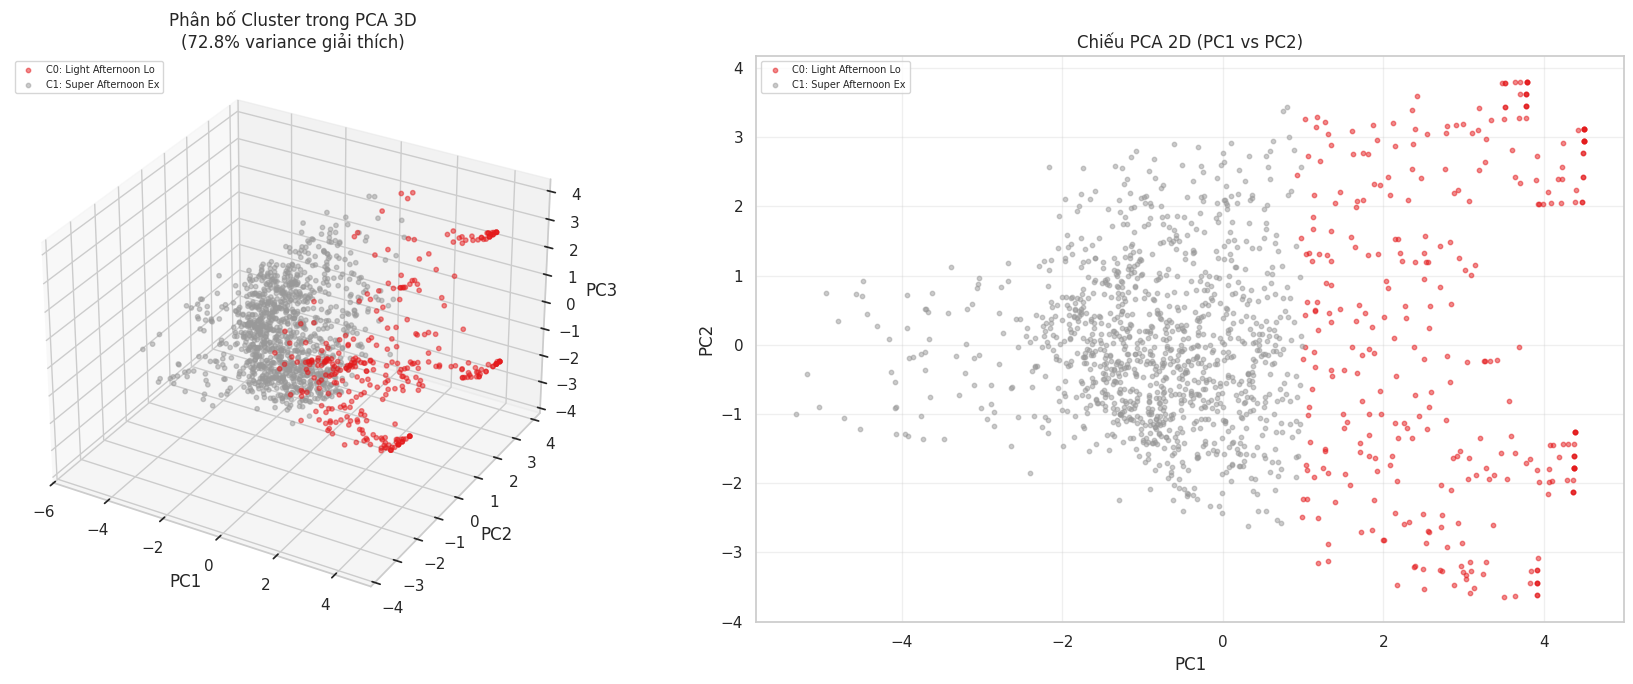

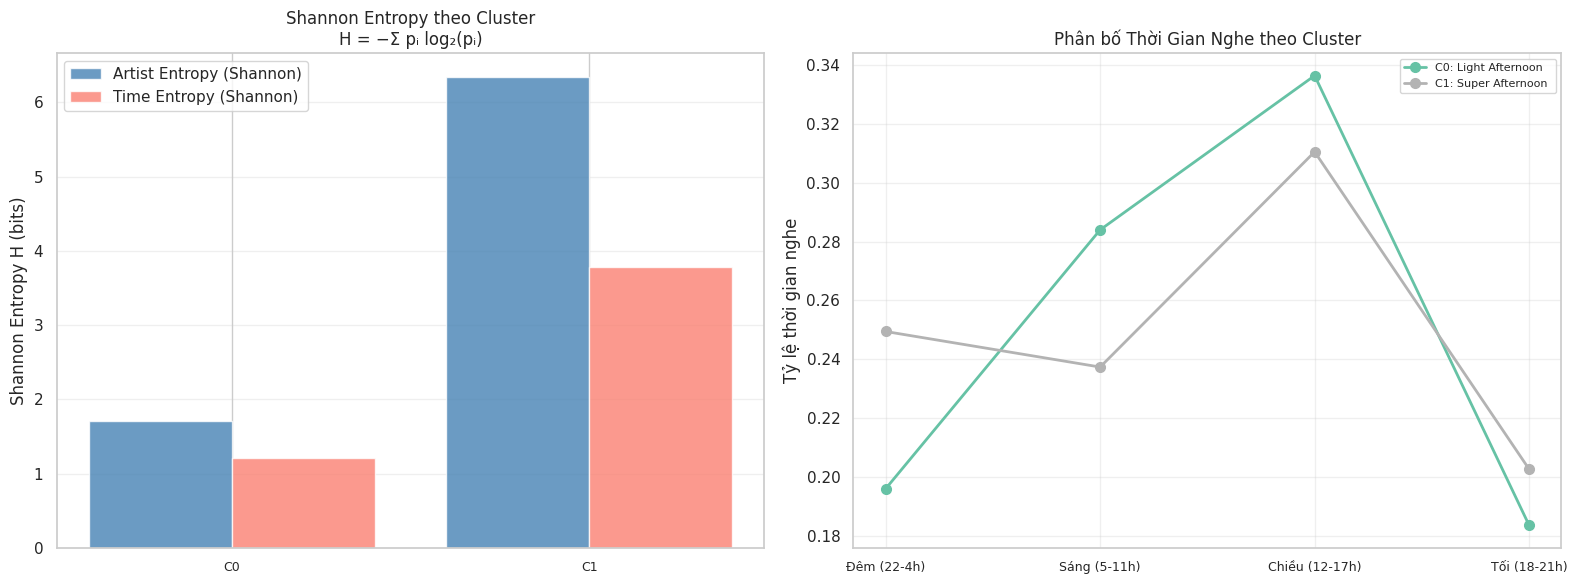

In [15]:
# ========== 12. VISUALIZATION: SCATTER PLOT 2D/3D TRONG PCA SPACE ==========
print("VISUALIZATION PHÂN CỤM")

# Lấy tọa độ PC từ PCA
pc_cols = [f'pc_arr[{i}]' for i in range(k_pca)]
sample_viz = final_results \
    .withColumn("pc_arr", vector_to_array("features")) \
    .select(
        "cluster", "user_type",
        *[F.col("pc_arr")[i].alias(f"pc{i+1}") for i in range(k_pca)]
    ) \
    .sample(fraction=0.05, seed=42).toPandas()

colors_palette = plt.cm.Set1(np.linspace(0, 0.9, optimal_k))
cluster_colors = {c: colors_palette[i]
                  for i, c in enumerate(sorted(sample_viz['cluster'].unique()))}

if k_pca >= 3:
    # -------- 3D Scatter --------
    fig = plt.figure(figsize=(18, 7))

    ax3d = fig.add_subplot(121, projection='3d')
    for c in sorted(sample_viz['cluster'].unique()):
        sub = sample_viz[sample_viz['cluster'] == c]
        lbl = f"C{c}: {label_map.get(c, '')[:18]}"
        ax3d.scatter(sub['pc1'], sub['pc2'], sub['pc3'],
                     c=[cluster_colors[c]], label=lbl, alpha=0.5, s=10)
    ax3d.set_xlabel('PC1'); ax3d.set_ylabel('PC2'); ax3d.set_zlabel('PC3')
    ax3d.set_title(f'Phân bố Cluster trong PCA 3D\n({cumulative_var[-1]*100:.1f}% variance giải thích)')
    ax3d.legend(fontsize=7, loc='upper left')

    ax2d = fig.add_subplot(122)
    for c in sorted(sample_viz['cluster'].unique()):
        sub = sample_viz[sample_viz['cluster'] == c]
        lbl = f"C{c}: {label_map.get(c, '')[:18]}"
        ax2d.scatter(sub['pc1'], sub['pc2'], c=[cluster_colors[c]],
                     label=lbl, alpha=0.5, s=10)
    ax2d.set_xlabel('PC1'); ax2d.set_ylabel('PC2')
    ax2d.set_title('Chiếu PCA 2D (PC1 vs PC2)')
    ax2d.legend(fontsize=7); ax2d.grid(True, alpha=0.3)

else:
    # -------- 2D Scatter --------
    fig, ax2d = plt.subplots(figsize=(10, 7))
    for c in sorted(sample_viz['cluster'].unique()):
        sub = sample_viz[sample_viz['cluster'] == c]
        lbl = f"C{c}: {label_map.get(c, '')[:20]}"
        ax2d.scatter(sub['pc1'], sub['pc2'], c=[cluster_colors[c]],
                     label=lbl, alpha=0.6, s=15)
    ax2d.set_xlabel('PC1'); ax2d.set_ylabel('PC2')
    ax2d.set_title(f'Phân bố Cluster trong PCA 2D\n({cumulative_var[-1]*100:.1f}% variance giải thích)')
    ax2d.legend(fontsize=9); ax2d.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ------- Panel 2: Profile dashboard -------
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# Shannon Entropy theo Cluster
x   = np.arange(len(cluster_profile))
w   = 0.4
axes2[0].bar(x - w/2, cluster_profile['avg_artist_entropy'], w,
             label='Artist Entropy (Shannon)', color='steelblue', alpha=0.8)
axes2[0].bar(x + w/2, cluster_profile['avg_time_entropy'],   w,
             label='Time Entropy (Shannon)',   color='salmon',    alpha=0.8)
axes2[0].set_xticks(x)
axes2[0].set_xticklabels([f"C{c}" for c in cluster_profile['cluster']], fontsize=9)
axes2[0].set_ylabel('Shannon Entropy H (bits)')
axes2[0].set_title('Shannon Entropy theo Cluster\nH = −Σ pᵢ log₂(pᵢ)')
axes2[0].legend(); axes2[0].grid(True, alpha=0.3, axis='y')

# Time pattern
time_cols   = ['avg_night_ratio', 'avg_morning_ratio', 'avg_afternoon_ratio', 'avg_evening_ratio']
time_labels = ['Đêm (22-4h)', 'Sáng (5-11h)', 'Chiều (12-17h)', 'Tối (18-21h)']
x_t         = np.arange(len(time_labels))
colors_line = plt.cm.Set2(np.linspace(0, 1, len(cluster_profile)))
for i, row in cluster_profile.iterrows():
    vals = [row[c] for c in time_cols]
    axes2[1].plot(x_t, vals, 'o-',
                  label=f"C{row['cluster']}: {row['user_type'][:16]}",
                  color=colors_line[i], linewidth=2, markersize=7)
axes2[1].set_xticks(x_t); axes2[1].set_xticklabels(time_labels, fontsize=9)
axes2[1].set_ylabel('Tỷ lệ thời gian nghe')
axes2[1].set_title('Phân bố Thời Gian Nghe theo Cluster')
axes2[1].legend(fontsize=8); axes2[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

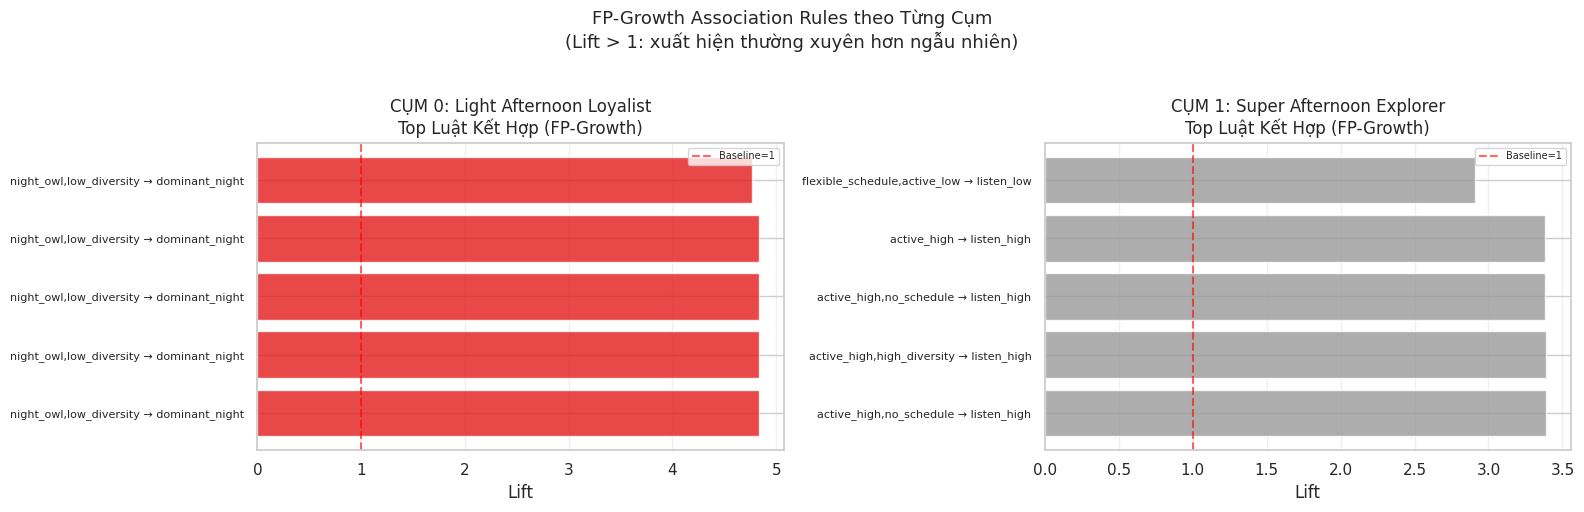

In [16]:
# ========== 13. VISUALIZATION FP-GROWTH (PER-CLUSTER) ==========
if len(all_rules_df) > 0:
    clusters_with_rules = list(all_rules_per_cluster.keys())
    n_clusters_viz = len(clusters_with_rules)
    cols_v = min(2, n_clusters_viz)
    rows_v = (n_clusters_viz + cols_v - 1) // cols_v

    fig, axes = plt.subplots(rows_v, cols_v,
                              figsize=(8 * cols_v, 5 * rows_v))
    if n_clusters_viz == 1:
        axes = [[axes]]
    elif rows_v == 1:
        axes = [axes]

    for idx, cluster_id in enumerate(clusters_with_rules):
        r, c = divmod(idx, cols_v)
        ax   = axes[r][c]
        rpd  = all_rules_per_cluster[cluster_id]
        top5 = rpd.nlargest(5, 'lift')

        top5['rule_label'] = top5.apply(
            lambda row: f"{','.join(row['antecedent'][:2])} → {','.join(row['consequent'][:1])}",
            axis=1
        )
        bars = ax.barh(range(len(top5)), top5['lift'],
                       color=colors_palette[clusters_with_rules.index(cluster_id)],
                       alpha=0.8, edgecolor='white')
        ax.set_yticks(range(len(top5)))
        ax.set_yticklabels(top5['rule_label'], fontsize=8)
        ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.6, label='Baseline=1')
        ax.set_xlabel('Lift')
        ax.set_title(f"CỤM {cluster_id}: {label_map.get(cluster_id, '')}\nTop Luật Kết Hợp (FP-Growth)")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis='x')

    # Ẩn subplot trống
    for idx in range(n_clusters_viz, rows_v * cols_v):
        r, c = divmod(idx, cols_v)
        axes[r][c].set_visible(False)

    plt.suptitle("FP-Growth Association Rules theo Từng Cụm\n"
                 "(Lift > 1: xuất hiện thường xuyên hơn ngẫu nhiên)",
                 fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("Không có rules để visualize")

In [17]:
# ========== 14. LƯU KẾT QUẢ ==========
print("LƯU KẾT QUẢ")

# Parquet chính
final_results.select(
    "user_id", "cluster", "user_type",
    "total_listens", "active_days",
    "night_ratio", "morning_ratio", "afternoon_ratio", "evening_ratio",
    "artist_entropy", "time_entropy",
    "avg_listen_hour", "hour_std"
).write.mode("overwrite").parquet("/kaggle/working/user_classification_improved.parquet")
print("Saved: user_classification_improved.parquet")

# Dashboard CSV
dashboard_df.drop(columns=['items'], errors='ignore') \
    .to_csv('/kaggle/working/dashboard_data_improved.csv', index=False)
print(f"Saved: dashboard_data_improved.csv ({len(dashboard_df):,} users)")

# Association Rules (mỗi cluster)
if len(all_rules_df) > 0:
    rules_save = all_rules_df.copy()
    rules_save['antecedent'] = rules_save['antecedent'].apply(lambda x: '|'.join(x))
    rules_save['consequent'] = rules_save['consequent'].apply(lambda x: '|'.join(x))
    rules_save.to_csv('/kaggle/working/association_rules_per_cluster.csv', index=False)
    print(f"Saved: association_rules_per_cluster.csv ({len(all_rules_df)} rules)")

# Metadata
metadata = {
    'total_users'            : len(dashboard_df),
    'clusters'               : optimal_k,
    'silhouette_score'       : final_silhouette,
    'feature_cols_raw'       : feature_cols,
    'pca_components'         : k_pca,
    'pca_explained_variance' : float(cumulative_var[-1]),
    'user_types'             : [str(v) for v in label_map.values()],
    'total_association_rules': len(all_rules_df),
    'clusters_with_rules'    : list(all_rules_per_cluster.keys()),
    'improvements_v2': [
        f'1. PCA reduced to {k_pca}D ({cumulative_var[-1]*100:.1f}% variance) — enables 2D/3D scatter',
        '2. Shannon Entropy H = -sum(p*log2(p)) replaces ad-hoc diversity_score',
        '3. FP-Growth runs PER-CLUSTER — cluster-specific actionable insights'
    ]
}
with open('/kaggle/working/metadata_improved.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("Saved: metadata_improved.json")

LƯU KẾT QUẢ


Saved: user_classification_improved.parquet
Saved: dashboard_data_improved.csv (28,764 users)
Saved: association_rules_per_cluster.csv (1138 rules)
Saved: metadata_improved.json


In [18]:
# ========== 15. TỔNG KẾT CẢI TIẾN ==========
print("=" * 65)
print("TỔNG KẾT CẢI TIẾN MODULE 1")
print("=" * 65)

print(f"""
CẢI TIẾN 1: PCA giảm xuống {k_pca} chiều
  Trước: 6 chiều PCA (chỉ giảm đa cộng tuyến nhưng không visual được)
  Sau  : {k_pca} chiều giữ {cumulative_var[-1]*100:.1f}% variance
         → Scatter Plot {'3D' if k_pca >= 3 else '2D'} trực quan, mỗi điểm = 1 user, màu = cluster
         → Có thể bảo vệ trực quan trước hội đồng

CẢI TIẾN 2: Shannon Entropy
  Công thức: H = −Σ pᵢ log₂(pᵢ)
  artist_entropy: đo mức độ đa dạng nghệ sĩ
  time_entropy  : đo mức độ đa dạng giờ nghe
  Nguồn: Shannon (1948) — Information Theory

CẢI TIẾN 3: FP-Growth TRONG TỪNG CỤM
    FP-Growth riêng cho từng persona cluster
         → Luật đặc trưng cho từng nhóm user
         → Insight có thể hành động (actionable)
         → Đây là bản chất KDD: Knowledge Discovery in Databases
""")

print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Số cụm: {optimal_k}")
print(f"PCA variance: {cumulative_var[-1]*100:.1f}% với {k_pca} chiều")
print(f"Tổng Association Rules: {len(all_rules_df)} (phân bổ trong {len(all_rules_per_cluster)} cụm)")
print(f"Rules theo cụm:")
for cluster_id, rpd in all_rules_per_cluster.items():
    print(f"  Cluster {cluster_id} ({label_map.get(cluster_id, '?')}): {len(rpd)} rules")

TỔNG KẾT CẢI TIẾN MODULE 1

CẢI TIẾN 1: PCA giảm xuống 3 chiều
  Trước: 6 chiều PCA (chỉ giảm đa cộng tuyến nhưng không visual được)
  Sau  : 3 chiều giữ 72.8% variance
         → Scatter Plot 3D trực quan, mỗi điểm = 1 user, màu = cluster
         → Có thể bảo vệ trực quan trước hội đồng

CẢI TIẾN 2: Shannon Entropy
  Công thức: H = −Σ pᵢ log₂(pᵢ)
  artist_entropy: đo mức độ đa dạng nghệ sĩ
  time_entropy  : đo mức độ đa dạng giờ nghe
  Nguồn: Shannon (1948) — Information Theory

CẢI TIẾN 3: FP-Growth TRONG TỪNG CỤM
    FP-Growth riêng cho từng persona cluster
         → Luật đặc trưng cho từng nhóm user
         → Insight có thể hành động (actionable)
         → Đây là bản chất KDD: Knowledge Discovery in Databases

Silhouette Score: 0.5799
Số cụm: 2
PCA variance: 72.8% với 3 chiều
Tổng Association Rules: 1138 (phân bổ trong 2 cụm)
Rules theo cụm:
  Cluster 0 (Light Afternoon Loyalist): 583 rules
  Cluster 1 (Super Afternoon Explorer): 555 rules
